In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import seaborn as sns

from lith_dictionary import lith_dict

In [2]:
catchment = pd.read_csv('Watersheds.csv')
lith = pd.read_csv('Intersections.csv')
assays = pd.read_csv('RTX_NURE_STREAM_FNL.csv')
lith.replace({'LITHOLOGY':lith_dict}, inplace = True)

lith_na_list = lith[lith.isnull()['LITHOLOGY']]['SAMPLEID'].tolist()
clean_lith = lith[~lith.SAMPLEID.isin(lith_na_list)]
clean_lith_plot = pd.melt(clean_lith, id_vars = ['LITHOLOGY'], value_vars = ['AREA'])

lith_area = pd.pivot_table(lith, index = 'SAMPLEID', values = 'AREA', columns = 'LITHOLOGY').fillna(0)
lith_pct = pd.pivot_table(lith, index = 'SAMPLEID', values = 'PERCENTAGE', columns = 'LITHOLOGY').fillna(0)
catchment.set_index('SAMPLEID', inplace = True)
assays.set_index('SAMPLEID', inplace = True)

<Axes: xlabel='value', ylabel='LITHOLOGY'>

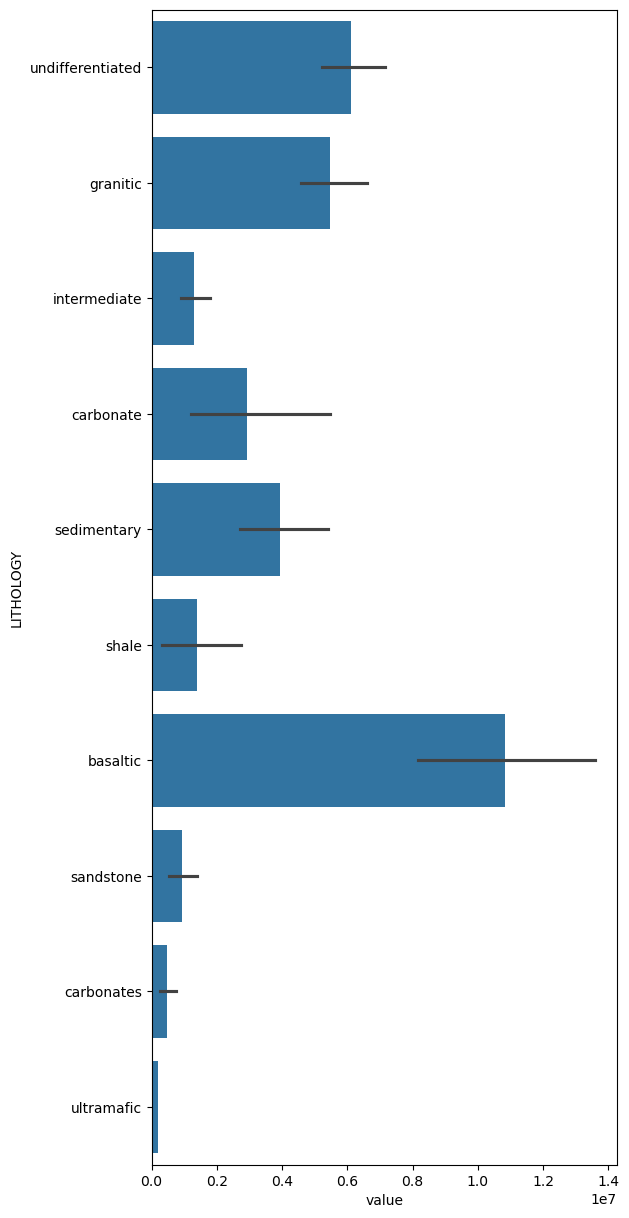

In [3]:
f, ax = plt.subplots(figsize=(6, 15))
sns.barplot(data = clean_lith_plot, y = 'LITHOLOGY', x = 'value')

In [4]:
# Removed Au.
assay_cols = ['WGS84_WORLD_LL_Calc_X',
        'WGS84_WORLD_LL_Calc_Y',
        'Ag_ppm', 
        'Al_pct', 
        'As_ppm', 
        'Ba_ppm', 
        'Be_ppm', 
        'Bi_ppm',
        'Ca_pct',
        'Cd_ppm',
        'Ce_ppm',
        'Co_ppm',
        'Cr_ppm', 
        'Cs_ppm',
        'Cu_ppm',
        'Fe_pct',
        'Ga_ppm',
        'Ge_ppm',
        'Hf_ppm',
        'In_ppm',
        'K_pct',
        'La_ppm',
        'Li_ppm',
        'Mg_pct', 
        'Mn_ppm', 
        'Mo_ppm', 
        'Na_pct', 
        'Nb_ppm', 
        'Ni_ppm',
        'P_ppm', 
        'Pb_ppm', 
        'Rb_ppm', 
        'S_pct', 
        'Sb_ppm', 
        'Sc_ppm', 
        'Se_ppm',
        'Sn_ppm', 
        'Sr_ppm', 
        'Ta_ppm', 
        'Te_ppm', 
        'Th_ppm', 
        'Ti_pct', 
        'Tl_ppm',
        'U_ppm', 
        'V_ppm', 
        'W_ppm', 
        'Y_ppm', 
        'Zn_ppm', 
        'Zr_ppm']

In [5]:
lith_assay = lith_pct.join(assays[assay_cols])
lith_assay_catch = lith_assay.join(catchment[['Shape_Area', 'Shape_Length']])

In [6]:
lith_assay_catch

,basaltic,carbonate,carbonates,granitic,intermediate,sandstone,sedimentary,shale,ultramafic,undifferentiated,...,Ti_pct,Tl_ppm,U_ppm,V_ppm,W_ppm,Y_ppm,Zn_ppm,Zr_ppm,Shape_Area,Shape_Length
SAMPLEID,,,,,,,,,,,,,,,,,,,,,
40122125,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,99.999640,...,0.466,0.393,1.76,83.1,1.365,21.7,74.8,96.4,0.000000,0.000370
40122126,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,100.000001,...,0.563,0.476,2.43,96.9,1.440,23.3,78.6,121.5,0.000185,0.121667
40122127,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,100.000008,...,0.534,0.582,1.82,93.7,2.560,19.6,98.0,100.5,0.000002,0.021111
40122128,0.000000,0.000000,0.000000,85.371483,0.0,0.0,0.000000,0.0,0.0,14.628517,...,0.702,0.602,3.41,109.0,3.460,41.7,128.5,80.6,0.001706,0.371111
40122129,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,100.000006,...,0.653,0.989,4.95,94.4,5.640,46.9,142.0,108.5,0.000000,0.006296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40430644,0.000000,8.339092,0.000000,24.335867,0.0,0.0,0.000000,0.0,0.0,14.329724,...,0.853,0.899,3.96,136.0,2.750,40.5,120.0,176.0,0.000488,0.204259
40430645,0.000000,8.591868,0.000000,27.616436,0.0,0.0,0.000000,0.0,0.0,12.058420,...,0.338,0.803,4.07,49.7,2.660,33.3,80.6,116.0,0.000430,0.127222
40430646,2.043730,0.000000,0.000000,27.712331,0.0,0.0,0.000000,0.0,0.0,21.265804,...,0.317,1.205,4.64,31.4,2.640,42.8,75.4,117.0,0.000318,0.116667


In [7]:
remove_sample_ids = [40429184,
 40304130,
 40428295,
 40304141,
 40312719,
 40429072,
 40309778,
 40428444,
 40426013,
 40429086,
 40312356,
 40303917,
 40428078,
 40426032,
 40303926,
 40312120,
 40430526,
 40304075,
 40312019,
 40430036,
 40430293,
 40307030,
 40430041,
 40304090,
 40312289,
 40430565,
 40311912,
 40429033,
 40312040,
 40428267,
 40430188,
 40430458]

In [8]:
reduced_lith_assay_catch = lith_assay_catch[~lith_assay_catch.index.isin(remove_sample_ids)]

watershed_tab_lists = ["Phyllosilicates", "Phyllosilicates_NoData", "Gossan", "Gossan_NoData", "Mag", "Mag_NoData", "Uranium", "Uranium_NoData"]
watershed_col_names = ['OBJECTID', 'SAMPLEID', 'COUNT', 'AREA', 'MIN', 'MAX', 'RANGE', 'MEAN', 'STD', 'SUM', 'VARIETY', 'MAJORITY',	'MAJORITY_COUNT', 'MAJORITY_PERCENT', 'MINORITY','MINORITY_COUNT', 'MINORITY_PERCENT', 'MEDIAN', 'PCT90']
table_name = 'TAB'

full_list = []
i = 0
for sheet in watershed_tab_lists:
    if i == 0:    
        table_col_names = [sheet+'_'+x for x in watershed_col_names]
        table_col_names[1] = 'SAMPLEID'
        table_col_names[2] = 'COUNT'
        new_table = pd.read_excel('Watershed_Sampling.xlsx', sheet_name = sheet, header = None, index_col='SAMPLEID', names = table_col_names)
        table_col_names_subset = [table_col_names[1], table_col_names[2], table_col_names[7], table_col_names[8], table_col_names[11], table_col_names[13], table_col_names[14], table_col_names[16]]
        reduced_lith_assay_catch = reduced_lith_assay_catch.join(new_table[table_col_names_subset[1:]])
    else:
        table_col_names = [sheet+'_'+x for x in watershed_col_names]
        table_col_names[1] = 'SAMPLEID'
        new_table = pd.read_excel('Watershed_Sampling.xlsx', sheet_name = sheet, header = None, index_col='SAMPLEID', names = table_col_names)
        table_col_names_subset = [table_col_names[7], table_col_names[8], table_col_names[11], table_col_names[13], table_col_names[14], table_col_names[16]]
        reduced_lith_assay_catch = reduced_lith_assay_catch.join(new_table[table_col_names_subset])
    full_list = full_list + table_col_names_subset
    i+=1

In [14]:
full_list

['SAMPLEID',
 'COUNT',
 'Phyllosilicates_MEAN',
 'Phyllosilicates_STD',
 'Phyllosilicates_MAJORITY',
 'Phyllosilicates_MAJORITY_PERCENT',
 'Phyllosilicates_MINORITY',
 'Phyllosilicates_MINORITY_PERCENT',
 'Phyllosilicates_NoData_MEAN',
 'Phyllosilicates_NoData_STD',
 'Phyllosilicates_NoData_MAJORITY',
 'Phyllosilicates_NoData_MAJORITY_PERCENT',
 'Phyllosilicates_NoData_MINORITY',
 'Phyllosilicates_NoData_MINORITY_PERCENT',
 'Gossan_MEAN',
 'Gossan_STD',
 'Gossan_MAJORITY',
 'Gossan_MAJORITY_PERCENT',
 'Gossan_MINORITY',
 'Gossan_MINORITY_PERCENT',
 'Gossan_NoData_MEAN',
 'Gossan_NoData_STD',
 'Gossan_NoData_MAJORITY',
 'Gossan_NoData_MAJORITY_PERCENT',
 'Gossan_NoData_MINORITY',
 'Gossan_NoData_MINORITY_PERCENT',
 'Mag_MEAN',
 'Mag_STD',
 'Mag_MAJORITY',
 'Mag_MAJORITY_PERCENT',
 'Mag_MINORITY',
 'Mag_MINORITY_PERCENT',
 'Mag_NoData_MEAN',
 'Mag_NoData_STD',
 'Mag_NoData_MAJORITY',
 'Mag_NoData_MAJORITY_PERCENT',
 'Mag_NoData_MINORITY',
 'Mag_NoData_MINORITY_PERCENT',
 'Uranium_MEAN',


In [82]:
reduced_lith_assay_catch.to_csv('joined_data_RTX_streams_global.csv', index=True)

In [83]:
with open('rtx_sample_list.pkl', 'wb') as fp:
    pickle.dump(lith_assay.index.tolist(), fp)